In [180]:
import sys, os
sys.path.append(os.path.abspath("../src"))

from nets import MLP
from burger_ground_truth import burgers_ground_truth_fd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import random


# Transport equation

Use 
\begin{align}
\dfrac{\partial u}{\partial t} + c\,\dfrac{\partial u}{\partial x} &= 0,
\end{align}
where $u(t,x)$ represent a quantity transported. Considerer the following normalization $U\,u' = u$. Then (1) becomes:
\begin{align}
\dfrac{\partial u'}{\partial t} + c\,\dfrac{\partial u'}{\partial x} &= 0,
\end{align}

# Case 1

Consider a waveform of the form $A(t)$ at the edge $x=0$, traveling along the segment with velocity $c$, then the solution to (1) is: 
$$u(x,y) = A\left(t-\dfrac{x}{c}\right)$$

**Objective** Given the information at two positions $x_1$ and $x_2$ of the waveform, then obtain the velocity $c$ at which it travels.

In [181]:
x_seg = 0.06  # mts
t_max = 2     # seg

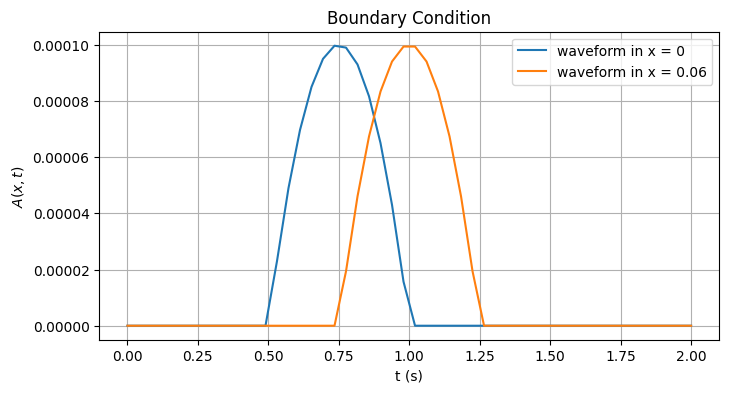

In [182]:
def wave_form(t, t_m, h=1e-4):
    """
    Pulso parabólico en el tiempo:
      - 0 fuera de [t_m/4, t_m/2]
      - parábola cóncava hacia abajo dentro
      - máximo h
    """

    t = np.asarray(t, dtype = float)
    a = t_m/4
    b = t_m/2
    # m = 0.5 * (a+b)

    k = 4.0 * h / (b-a)**2

    y = np.zeros_like(t)
    mask = (t>=a) & (t<=b)
    y[mask] = k * (t[mask]-a) * (b-t[mask])

    return y.item() if y.ndim == 0 else y


ts = np.linspace(0, t_max, 50)
A_0 = wave_form(ts, 2)

c = 0.06/0.25
dt_shift = 0.25
A_shift = wave_form(ts - dt_shift, t_m=2.0)   # shift a la derecha (retardo)



#grafica 
plt.figure(figsize=(8, 4))
plt.plot(ts, A_0, label='waveform in x = 0')
plt.plot(ts, A_shift, label='waveform in x = 0.06')  # muestra el retardo
plt.title('Boundary Condition')
plt.xlabel('t (s)')
plt.ylabel('$A(x,t)$')
plt.grid()
plt.legend()
plt.show()

# PINNverse

In [183]:
net = MLP(2, 1, 3, 10, activation_fn = nn.Tanh())

In [184]:
# normalization 
U = 1e-4

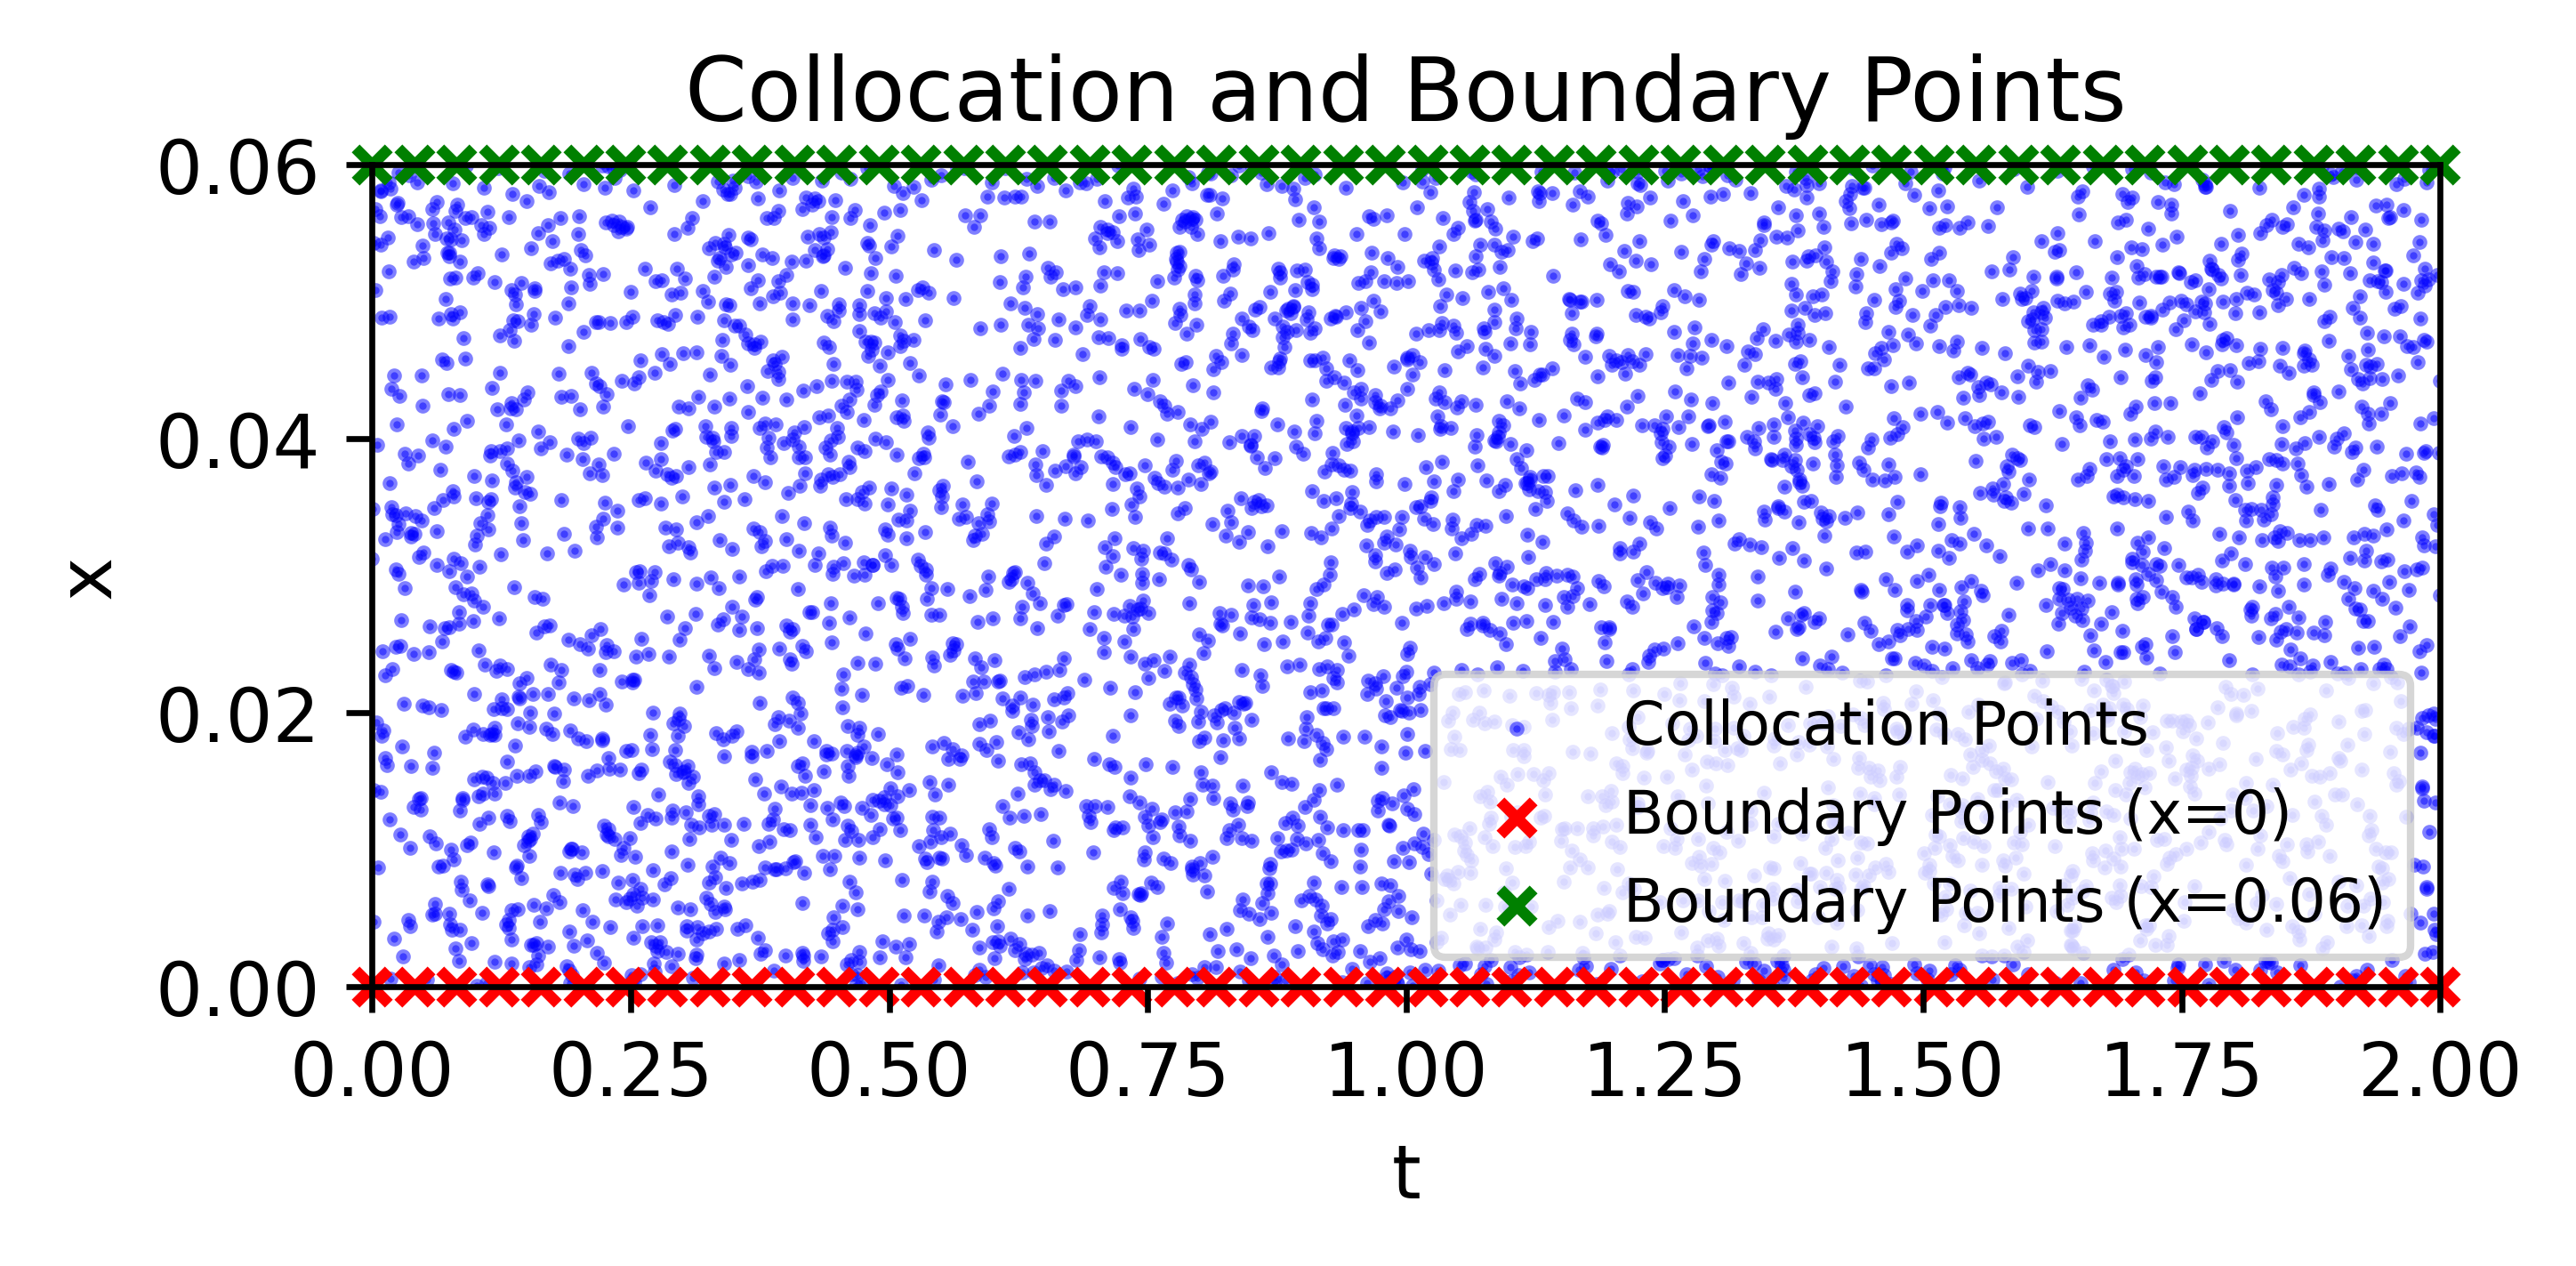

In [185]:
# colocation points 
n_f = 4000
x_c = x_seg*torch.rand(n_f, 1, dtype=torch.float32) 
t_c = 2*torch.rand(n_f, 1, dtype=torch.float32) 
x_c.requires_grad_(True)
t_c.requires_grad_(True)

# Data points
t_d = torch.tensor(ts, dtype=torch.float32).reshape(-1, 1)
x_1 = torch.zeros_like(t_d)
x_2 = x_seg*torch.ones_like(t_d)
u_1 = torch.tensor(A_0, dtype=torch.float32).reshape(-1, 1)
u_2 = torch.tensor(A_shift, dtype=torch.float32).reshape(-1, 1)

# Noise
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# def add_hetero_noise_abs(y, zeta=0.25, eps=1e-8):
#     sigma = zeta * (y.abs() + eps)   # std siempre positiva
#     return y + sigma * torch.randn_like(y)

# u_1_noisy = add_hetero_noise_abs(u_1, zeta=0.20)
# u_2_noisy = add_hetero_noise_abs(u_2, zeta=0.20)

def add_noise_mixed_auto(y, zeta=0.10, frac=0.02):
    sigma0 = frac * y.abs().max()          # o frac * y.std()
    sigma = zeta * y.abs() + sigma0
    return y + sigma * torch.randn_like(y)

u_1_noisy = add_noise_mixed_auto(u_1, zeta=0.20)
u_2_noisy = add_noise_mixed_auto(u_2, zeta=0.20)

# Plot
plt.figure(figsize=(5, 2), dpi=600)
plt.scatter(t_c.detach().numpy(), x_c.detach().numpy(), s=1, alpha=0.5, c='b', label='Collocation Points')
plt.scatter(t_d.detach().numpy(), x_1.detach().numpy(), s=20, c='r', marker = 'x', clip_on=False, label='Boundary Points (x=0)')
plt.scatter(t_d.detach().numpy(), x_2.detach().numpy(), s=20, c='g', marker = 'x', clip_on=False, label='Boundary Points (x=0.06)')
plt.title('Collocation and Boundary Points')
plt.legend(fontsize=8)
plt.xlim(0, 2.0)
plt.ylim(0, x_seg)   
plt.xlabel('t')
plt.ylabel('x')
plt.show()


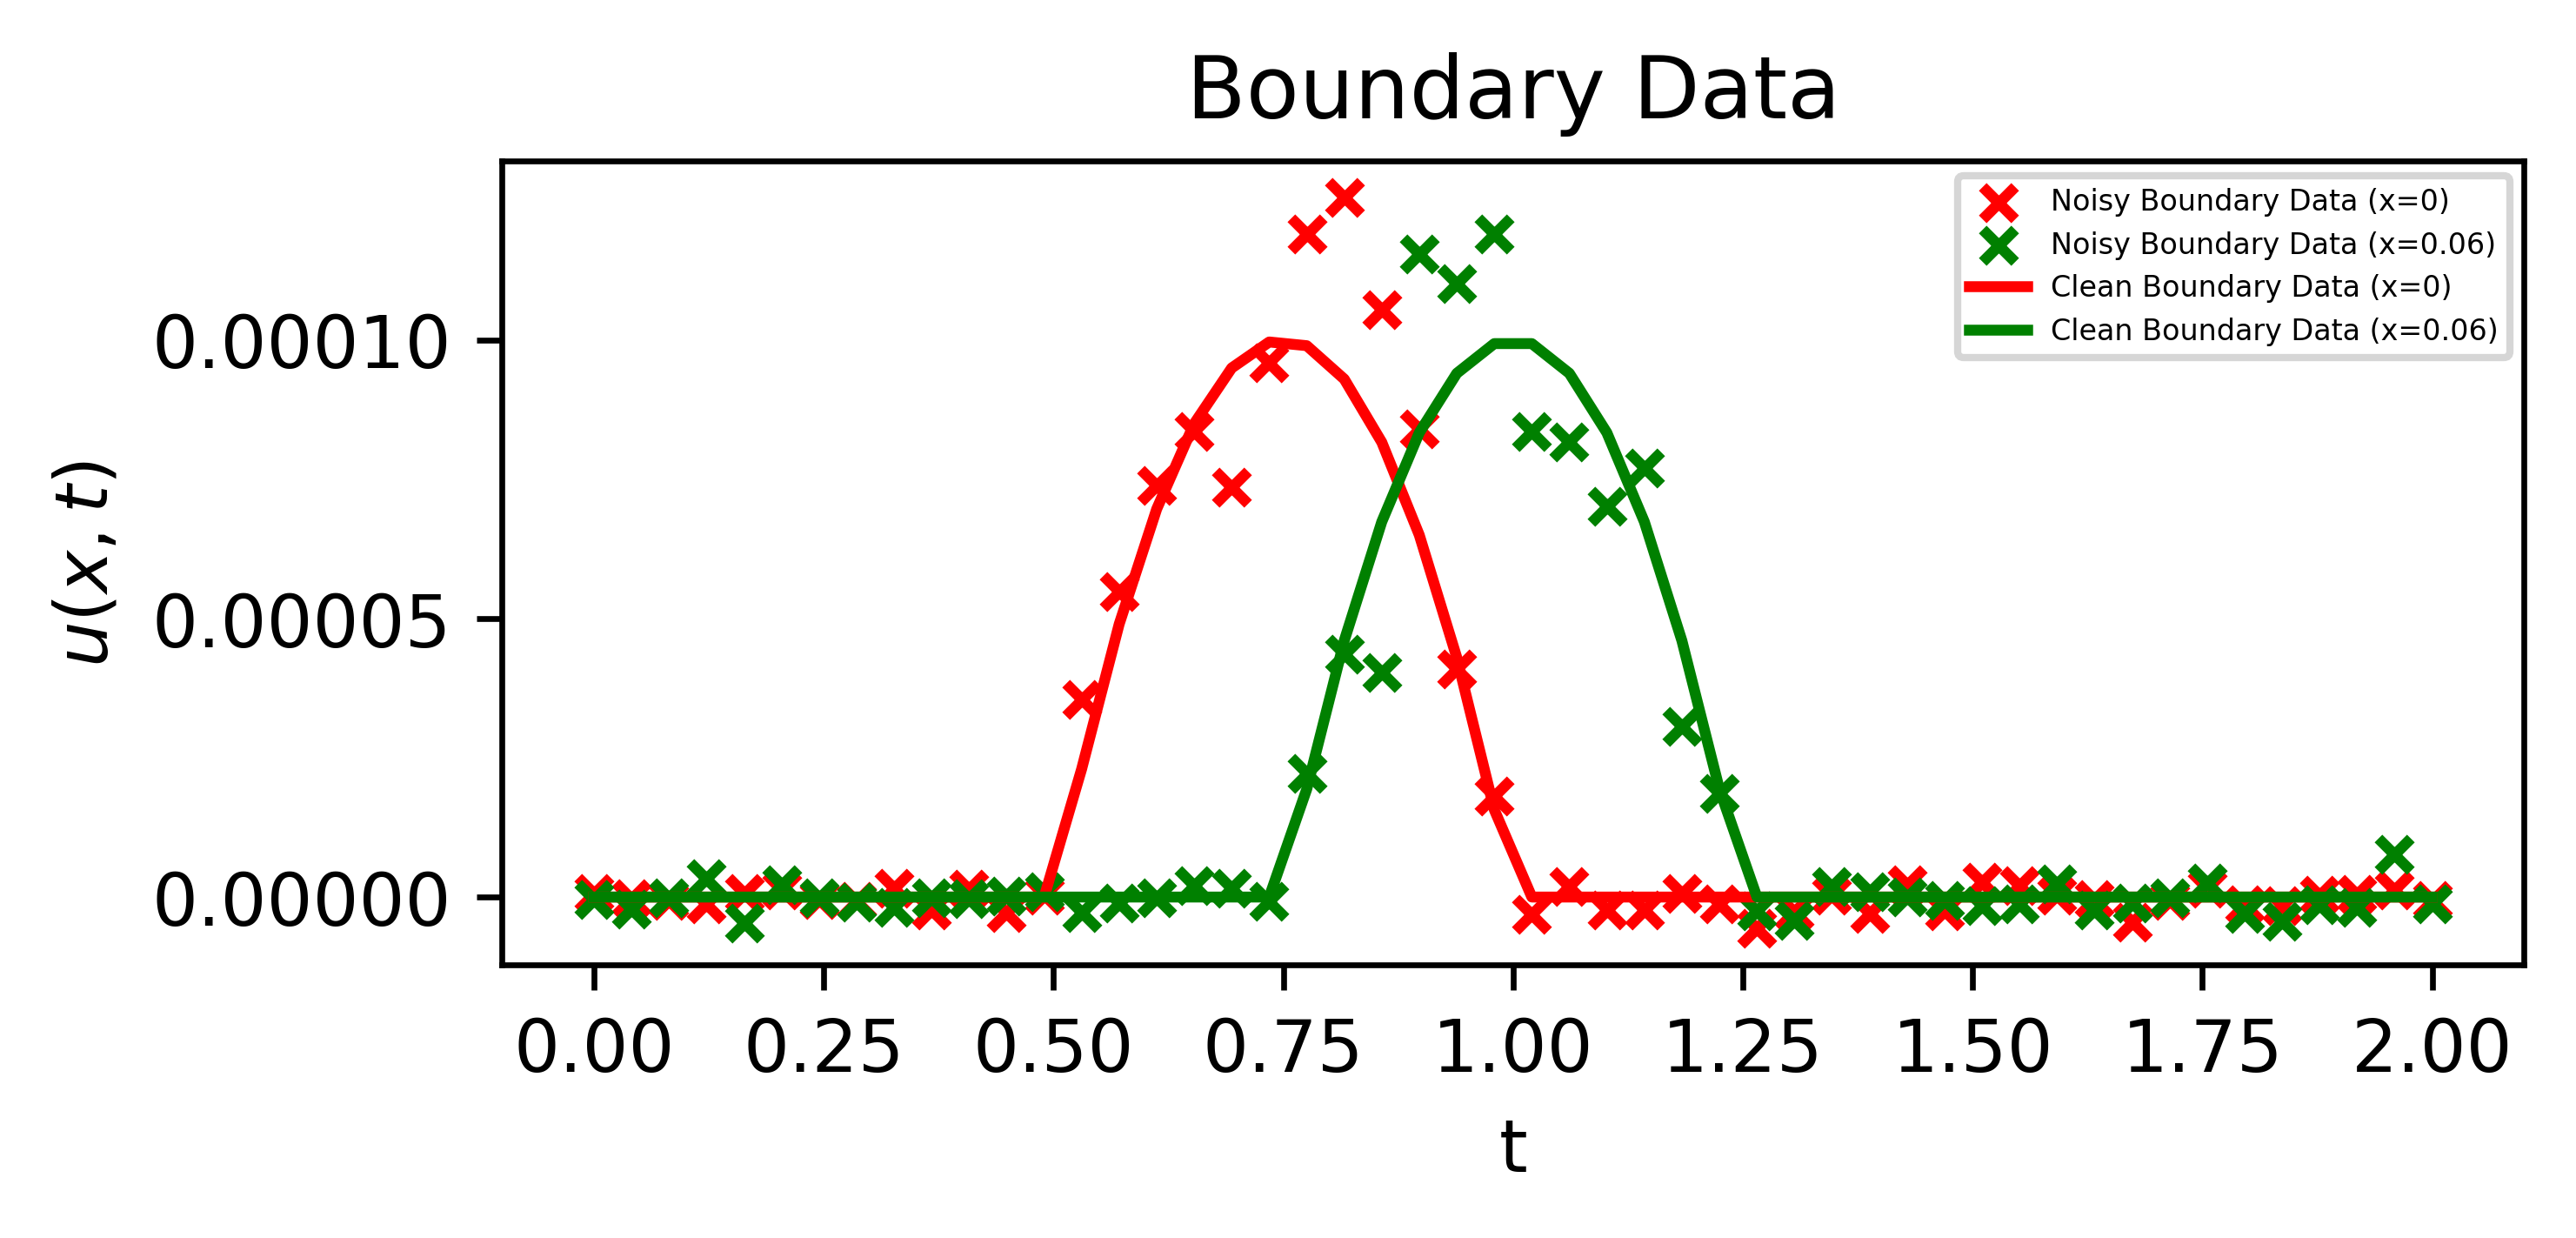

In [186]:
# plot noise data
plt.figure(figsize=(5, 2), dpi=600)
plt.scatter(t_d.detach().numpy(), u_1_noisy.detach().numpy(), s=20, c='r', marker = 'x', clip_on=False, label='Noisy Boundary Data (x=0)')
plt.scatter(t_d.detach().numpy(), u_2_noisy.detach().numpy(), s=20, c='g', marker = 'x', clip_on=False, label='Noisy Boundary Data (x=0.06)')
plt.plot(t_d.detach().numpy(), u_1.detach().numpy(), c='r', label='Clean Boundary Data (x=0)')
plt.plot(t_d.detach().numpy(), u_2.detach().numpy(), c='g', label='Clean Boundary Data (x=0.06)')
plt.title('Boundary Data')
plt.legend(fontsize=4)
plt.xlabel('t')
plt.ylabel('$u(x,t)$')
plt.show()

In [187]:
c_v = nn.Parameter(torch.tensor(1.0, dtype=torch.float32), requires_grad=True)

In [188]:
def transport_residual():
    u = net(x_c,t_c)
    u_t = torch.autograd.grad(u, t_c, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_c, torch.ones_like(u), create_graph=True)[0]
    r = u_t + c_v*u_x
    return torch.mean(r**2)

In [189]:
def data_loss():
    u_data_1 = net(x_1, t_d)
    u_data_2 = net(x_2, t_d)
    r_data_1 = torch.mean((u_data_1 - u_1_noisy/U)**2)
    r_data_2 = torch.mean((u_data_2 - u_2_noisy/U)**2)
    return r_data_1 + r_data_2

# MDMM

In [190]:
lam_f = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
rho_f = 5.0 #damping

In [191]:
def compute_loss():
    Ld = data_loss()
    Lr = transport_residual()

    inf_r = -Lr

    J = Ld + (lam_f * inf_r + 0.5 * rho_f * inf_r**2)
    
    return J, Ld, Lr, c_v, lam_f

In [192]:
compute_loss()

(tensor(0.2599, grad_fn=<AddBackward0>),
 tensor(0.2599, grad_fn=<AddBackward0>),
 tensor(0.0004, grad_fn=<MeanBackward0>),
 Parameter containing:
 tensor(1., requires_grad=True),
 Parameter containing:
 tensor(0., requires_grad=True))

# Training 

In [193]:
dict = {
    "J":[], 
    "Ld":[],  
    "Lr":[],
    "c_value": [],
    "lam_f": []
}

In [194]:
optimizer = torch.optim.Adam([
    {'params': net.parameters(), 'lr': 1e-3},
    {'params': c_v, 'lr': 1e-3},
    {'params': lam_f, 'lr': -1e-3}
])

In [195]:
epochs = 10000
for ep in range(epochs):
    optimizer.zero_grad()
    J, Ld, Lr, c_t, lam_f_t = compute_loss()
    J.backward()
    optimizer.step()

    dict["J"].append(J.item())
    dict["Ld"].append(Ld.item())
    dict["Lr"].append(Lr.item())
    dict["c_value"].append(c_t.item())
    dict["lam_f"].append(lam_f_t.item())

    if ep % 500 == 0:
        print(f"Epoch {ep}: Total Loss = {J.item():.6e}, Data Loss = {Ld.item():.6e}, Physics Loss = {Lr.item():.6e}, c = {c_t.item():.4f}, lam_f = {lam_f_t.item():.4f}. ")

Epoch 0: Total Loss = 2.598543e-01, Data Loss = 2.598538e-01, Physics Loss = 4.295858e-04, c = 0.9990, lam_f = -0.0010. 
Epoch 500: Total Loss = 5.413894e-02, Data Loss = 5.379959e-02, Physics Loss = 8.011751e-04, c = 0.7359, lam_f = -0.4216. 
Epoch 1000: Total Loss = 1.316961e-02, Data Loss = 1.311675e-02, Physics Loss = 1.197369e-04, c = 0.2683, lam_f = -0.4412. 
Epoch 1500: Total Loss = 1.217002e-02, Data Loss = 1.209179e-02, Physics Loss = 1.726000e-04, c = 0.2591, lam_f = -0.4528. 
Epoch 2000: Total Loss = 1.168147e-02, Data Loss = 1.156693e-02, Physics Loss = 2.409761e-04, c = 0.2567, lam_f = -0.4748. 
Epoch 2500: Total Loss = 1.144921e-02, Data Loss = 1.124829e-02, Physics Loss = 3.847793e-04, c = 0.2567, lam_f = -0.5213. 
Epoch 3000: Total Loss = 1.133326e-02, Data Loss = 1.109615e-02, Physics Loss = 3.959842e-04, c = 0.2574, lam_f = -0.5979. 
Epoch 3500: Total Loss = 1.116795e-02, Data Loss = 1.094237e-02, Physics Loss = 3.273988e-04, c = 0.2574, lam_f = -0.6884. 
Epoch 4000: 

# Results

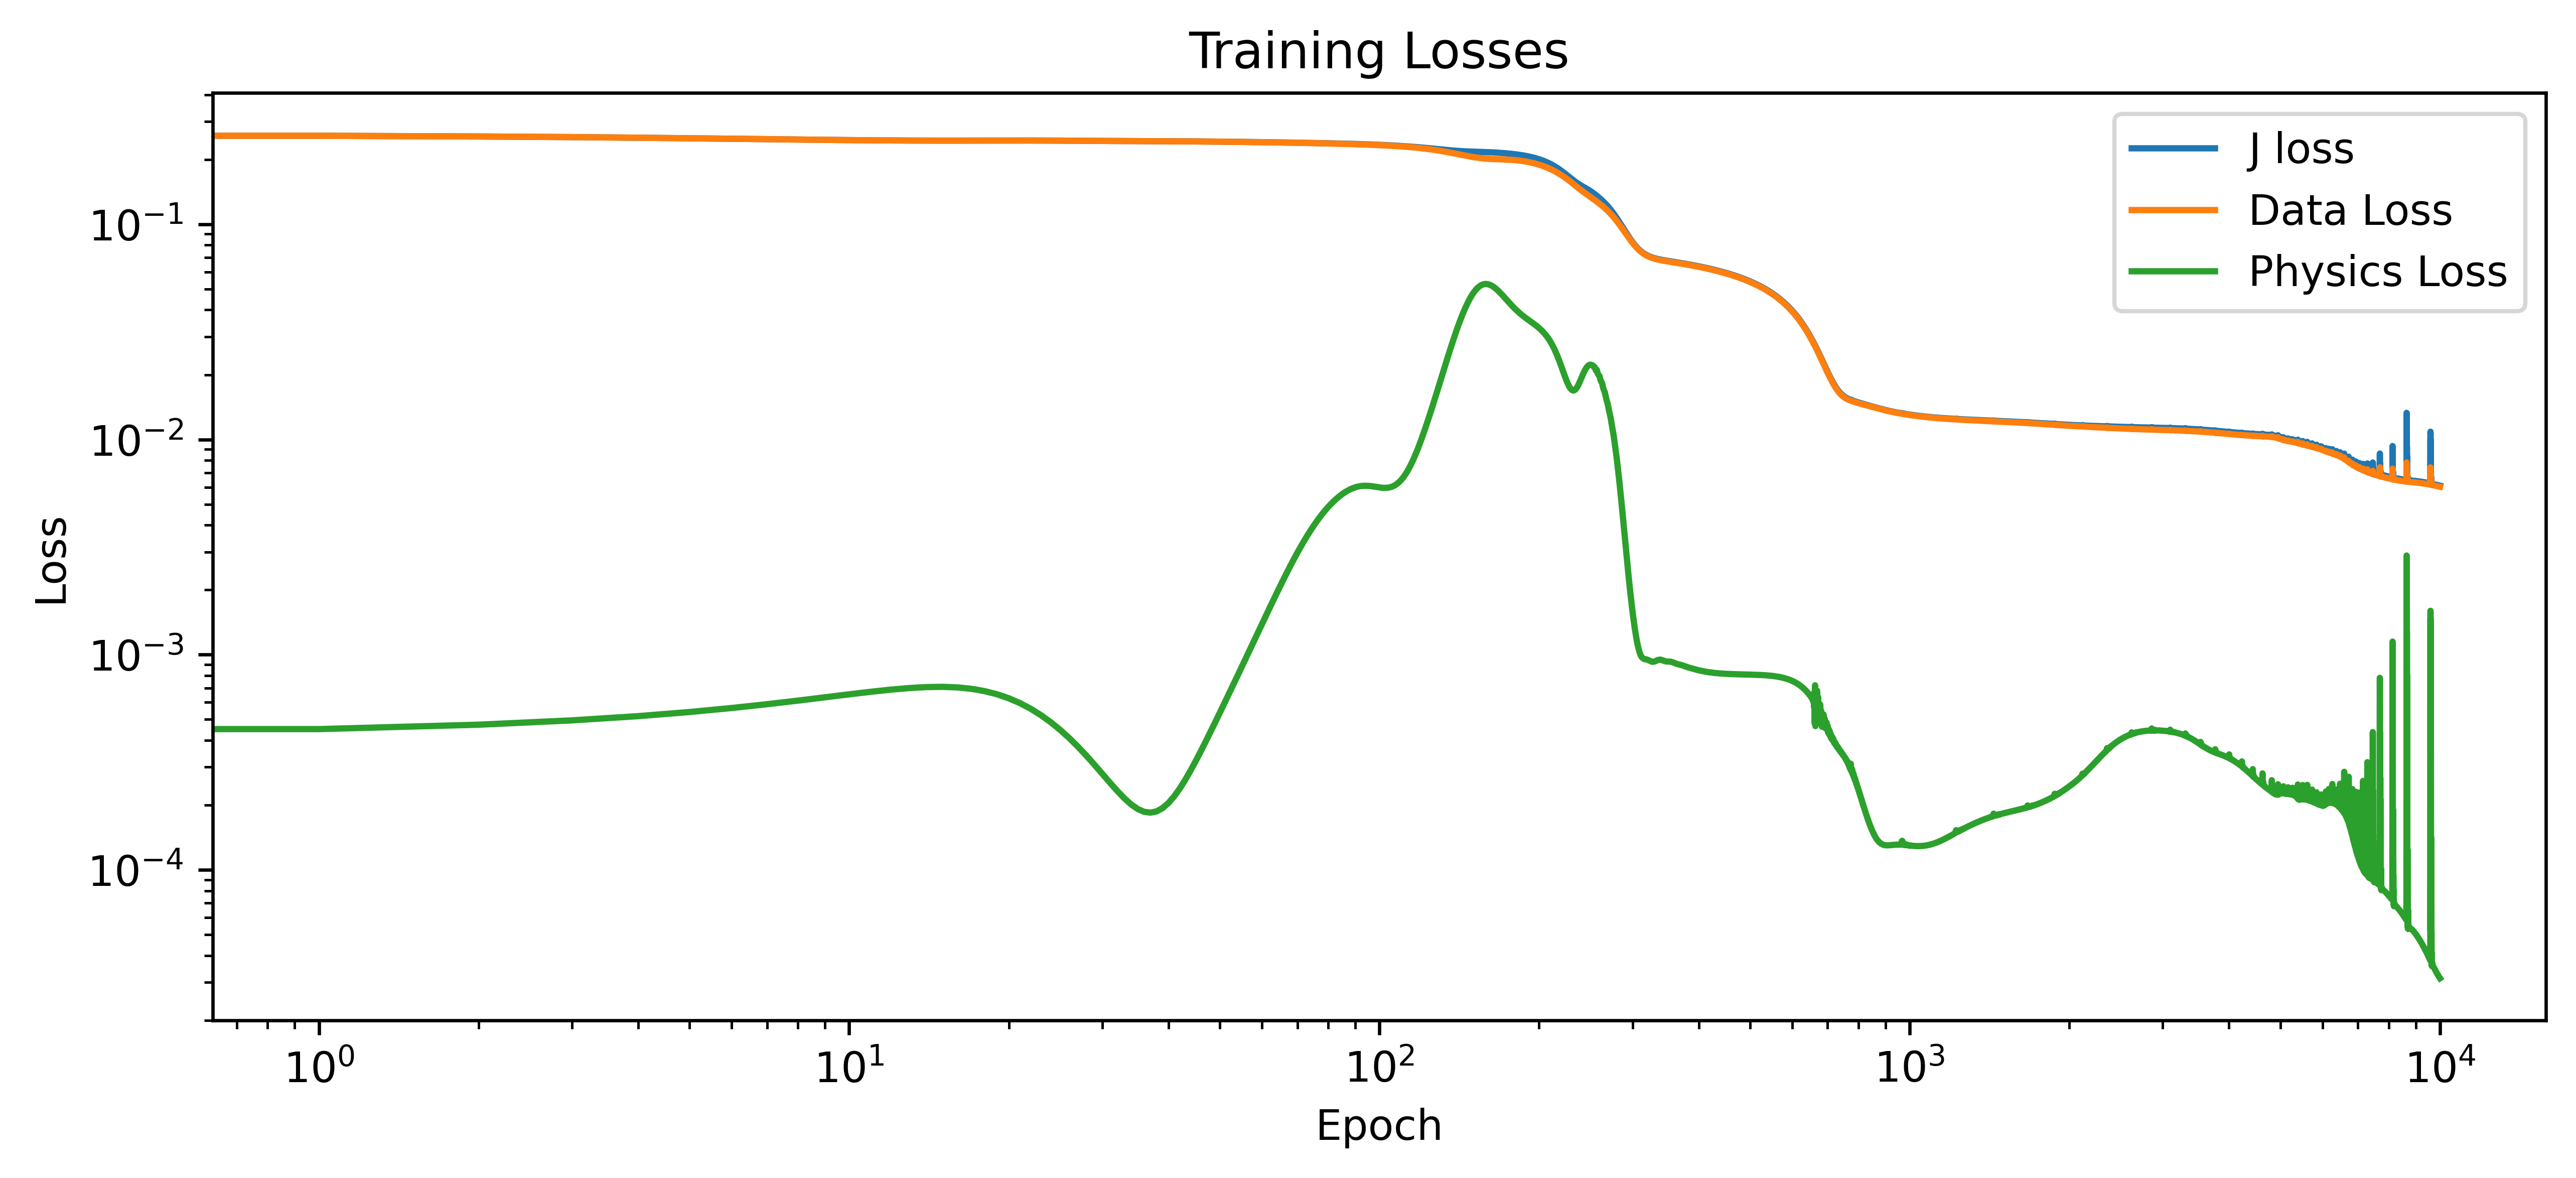

In [176]:
# Loss plot
plt.figure(figsize=(10, 4), dpi=600)
plt.plot(dict["J"], label="J loss")
plt.plot(dict["Ld"], label="Data Loss")
plt.plot(dict["Lr"], label="Physics Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xscale("log")
plt.title("Training Losses")
plt.legend()
plt.show()

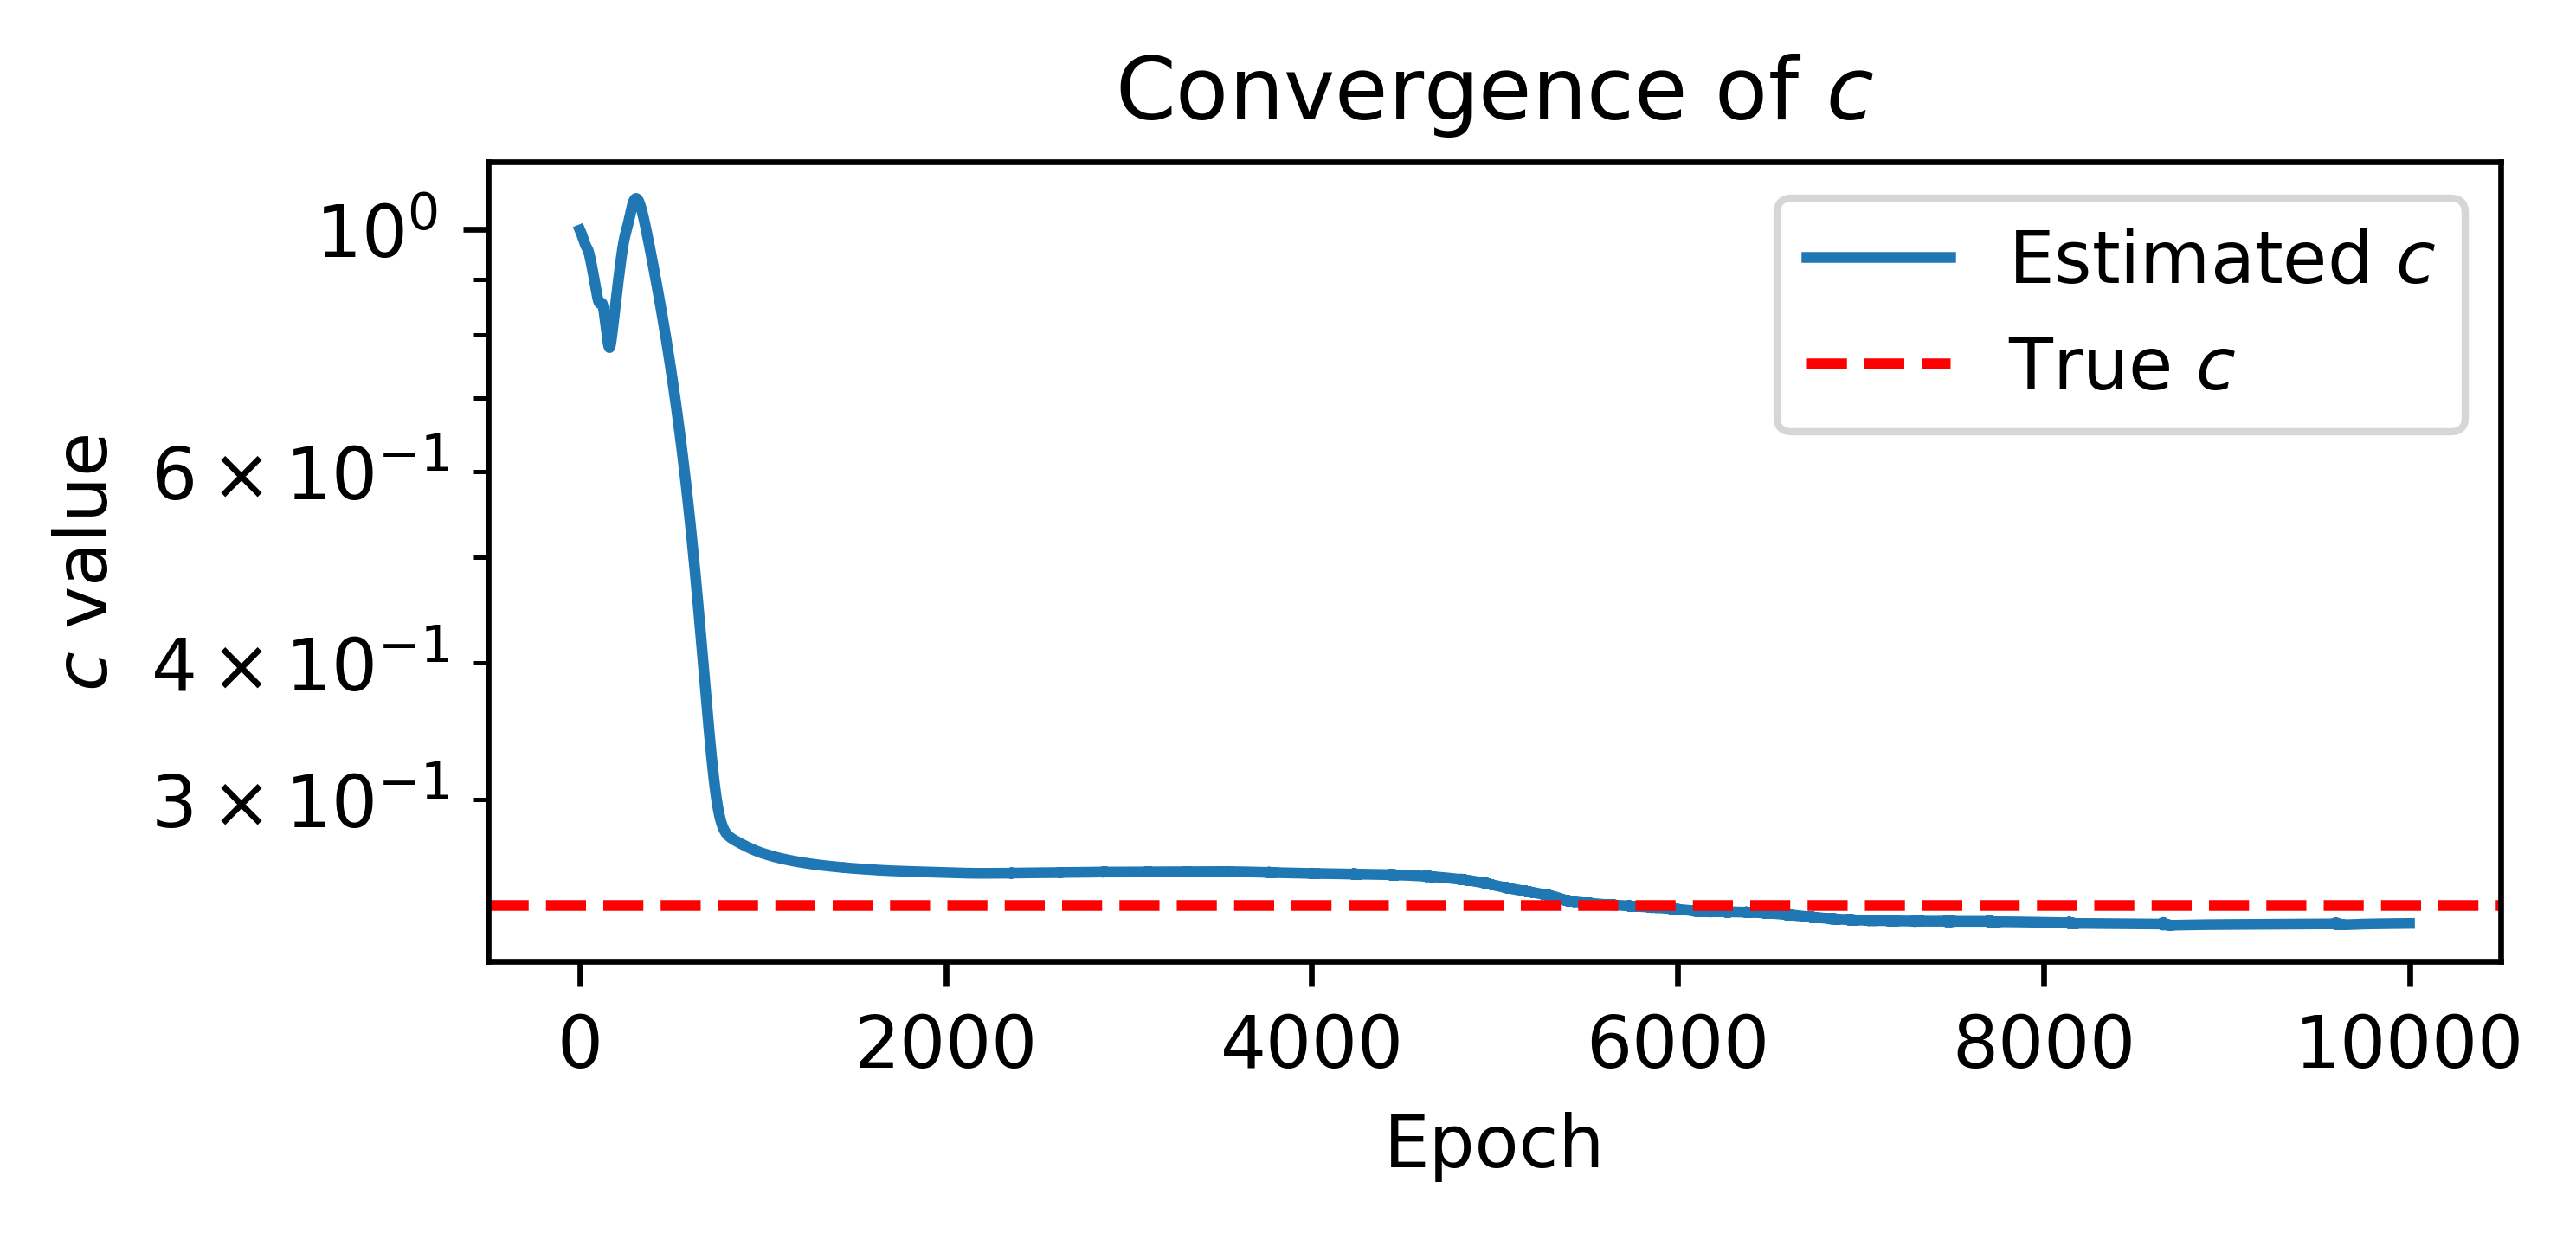

In [177]:
# Convergence nu 
plt.figure(figsize=(5, 2), dpi=600)
plt.plot(dict["c_value"], label="Estimated $c$")
plt.axhline(c, color='r', linestyle='--', label="True $c$")
plt.xlabel("Epoch")
plt.ylabel("$c$ value")
plt.yscale("log")
plt.title("Convergence of $c$")
plt.legend()
plt.show()

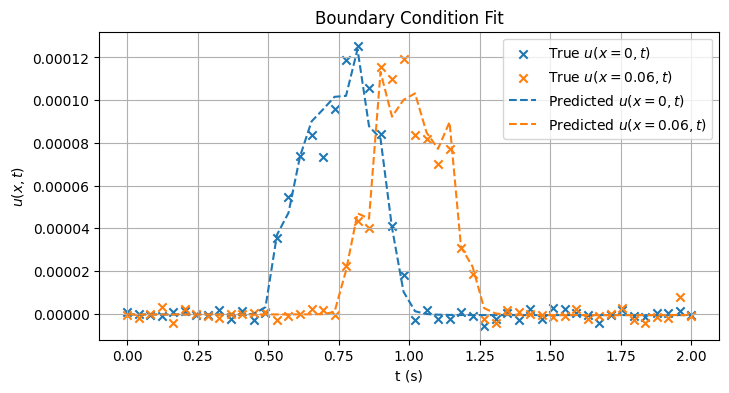

In [178]:
u_pred_1 = net(x_1, t_d).detach().numpy() * U
u_pred_2 = net(x_2, t_d).detach().numpy() * U

# grafico
plt.figure(figsize=(8, 4))
plt.scatter(ts, u_1_noisy.detach().numpy(), marker = 'x', label='True $u(x=0, t)$')
plt.scatter(ts, u_2_noisy.detach().numpy(), marker = 'x', label='True $u(x=0.06, t)$')
plt.plot(ts, u_pred_1, label='Predicted $u(x=0, t)$', linestyle='dashed')
plt.plot(ts, u_pred_2, label='Predicted $u(x=0.06, t)$', linestyle='dashed')
plt.title('Boundary Condition Fit')
plt.xlabel('t (s)')
plt.ylabel('$u(x,t)$')
plt.grid()
plt.legend()
plt.show()

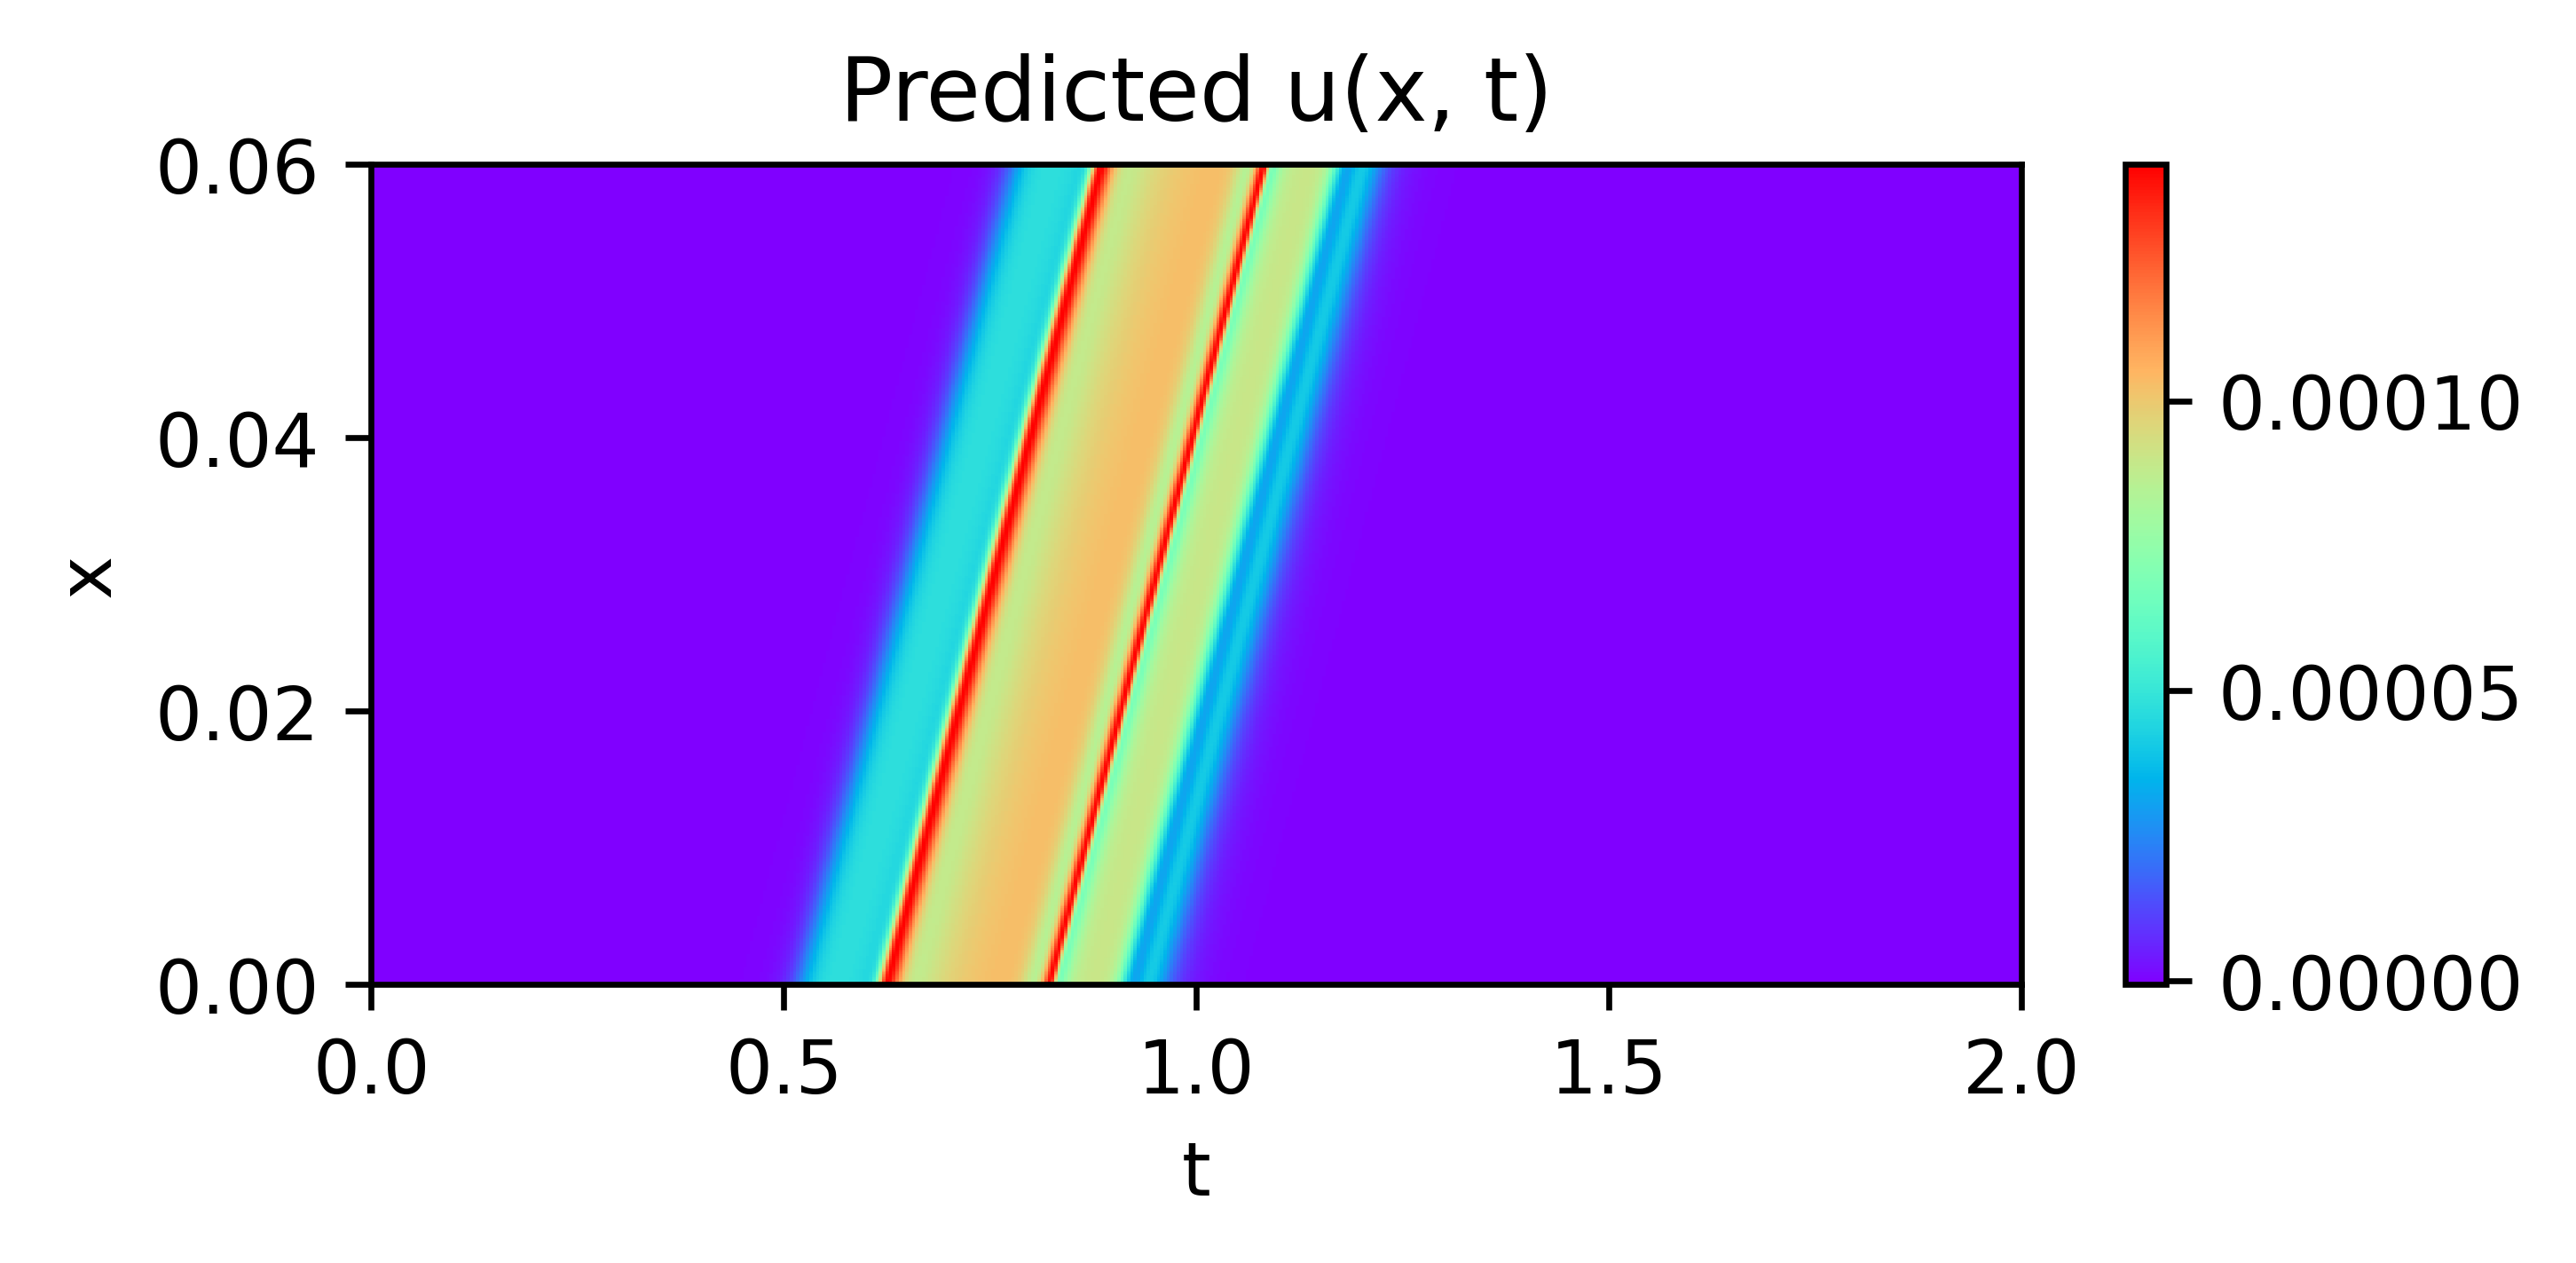

In [179]:
# Plot prediction
x_test = torch.linspace(0, x_seg, 500).unsqueeze(1)
t_test = torch.linspace(0, 2, 500).unsqueeze(1)
X_test, T_test = torch.meshgrid(x_test.squeeze(), t_test.squeeze(), indexing='ij')
X_test = X_test.reshape(-1, 1)
T_test = T_test.reshape(-1, 1)
with torch.no_grad():
    u_pred = net(X_test, T_test).reshape(500, 500) * U  

plt.figure(figsize=(5, 2), dpi=600)
plt.pcolormesh(T_test.reshape(500, 500), X_test.reshape(500, 500), u_pred, shading="auto", cmap=cm.rainbow)
plt.colorbar()
plt.ylim(0., x_seg)
plt.xlim(0, 2.0)
plt.title("Predicted u(x, t)")
plt.ylabel("x")
plt.xlabel("t")
plt.show()